
# Detector-level Shack-Hartmann WFS: lenslet spots and centroiding

This notebook upgrades the previous geometric SH-WFS model.

The old model measured local wavefront slopes directly by numerical gradients:

wavefront phase -> local mean gradient -> slope vector


Here we simulate a more realistic detector-level chain:

wavefront phase over each lenslet
        -> local Fourier diffraction spot
        -> photon/read-noise detector image
        -> center-of-gravity centroid
        -> centroid shift vector
        -> response-matrix reconstruction

The calibration is response-matrix based: centroid shifts remain in detector-pixel units, and the response matrix maps modal coefficients directly into centroid shifts.


In [18]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make sure local project modules can be imported when the notebook is run from this folder.
sys.path.append(str(Path.cwd()))

from zernike import make_pupil_grid, generate_zernike_modes, synthesize_wavefront
from reconstruction import synthesize_from_coefficients, residual_wavefront, rms
from shwfs_detector import (
    lenslet_spot_from_phase,
    add_detector_noise,
    centroid,
    build_detector_response_matrix,
    measure_centroid_shifts,
    reconstruct_from_centroid_shifts,
    centroid_noise_scan,
)



## 1. Pupil, Zernike modes, and a known test wavefront

We first create a moderate-size pupil grid and a low-order Zernike basis.  The test wavefront is intentionally built from modes inside the reconstruction basis.  Therefore, in the noiseless case, a good detector-level model should recover the input coefficients with a small residual.


In [24]:
N = 256
D = 1.0
n_lenslets = 8
min_fill = 0.50
pad_factor = 4
max_radial_order = 4

centroid_threshold = 0.05
read_noise_e = 3.0

X, Y, rho, theta, pupil_mask, dx = make_pupil_grid(N=N, diameter=D)
modes = generate_zernike_modes(
    rho,
    theta,
    pupil_mask,
    max_radial_order=max_radial_order,
    include_piston=False,
    normalization=True,
)

true_coeffs = {
    "Z2_+0": 0.25,   # defocus-like
    "Z2_+2": 0.12,   # astigmatism cosine
    "Z3_+1": 0.08,   # coma cosine
    "Z3_-1": -0.05,  # coma sine
}

W_true = synthesize_wavefront(modes, true_coeffs, pupil_mask, remove_mean=True)

print(f"Number of Zernike modes: {len(modes)}")
print(f"Input wavefront RMS: {rms(W_true, pupil_mask):.4f} rad")


Number of Zernike modes: 14
Input wavefront RMS: 0.2927 rad


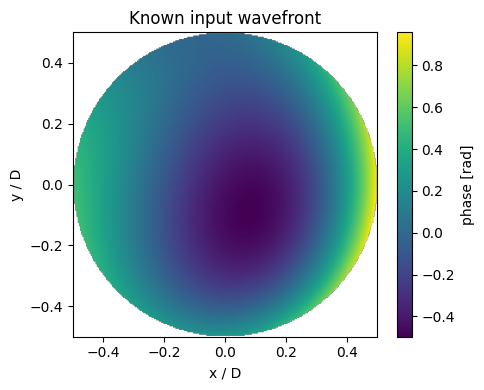

In [20]:
plt.figure(figsize=(5, 4))
plt.imshow(W_true, origin="lower", extent=[-0.5, 0.5, -0.5, 0.5])
plt.colorbar(label="phase [rad]")
plt.title("Known input wavefront")
plt.xlabel("x / D")
plt.ylabel("y / D")
plt.tight_layout()
plt.show()


## 2. One lenslet spot: ideal, aberrated, and noisy

This is the main conceptual upgrade.  Instead of directly reading the local gradient, each lenslet forms a focal-plane spot.  A wavefront tilt shifts the spot; higher-order phase inside the sub-aperture can also distort it.


In [37]:
A_tmp, names_tmp, centers, lenslet_masks, reference = build_detector_response_matrix(
    modes,
    pupil_mask,
    X,
    Y,
    n_lenslets=n_lenslets,
    min_fill=min_fill,
    pad_factor=pad_factor,
)

# Choose the valid lenslet closest to the pupil center.
central_idx = int(np.argmin(np.sum(centers**2, axis=1)))
central_mask = lenslet_masks[central_idx]

spot0 = lenslet_spot_from_phase(np.zeros_like(W_true), central_mask, pad_factor=8)
spot_ab = lenslet_spot_from_phase(W_true, central_mask, pad_factor=8)
spot_noisy = add_detector_noise(spot_ab, photons=3_000, read_noise_e=3.0, seed=10)

print("Reference centroid:", centroid(spot0))
print("Aberrated centroid:", centroid(spot_ab))
print(
    "Noisy centroid:",
    centroid(
        spot_noisy,
        threshold_fraction=centroid_threshold,
        subtract_minimum=True,
    )
)

Reference centroid: (0.5000000000000001, -0.5)
Aberrated centroid: (0.27626808573390854, -0.5399801045541648)
Noisy centroid: (-0.31158566772958796, 0.2864105859270597)


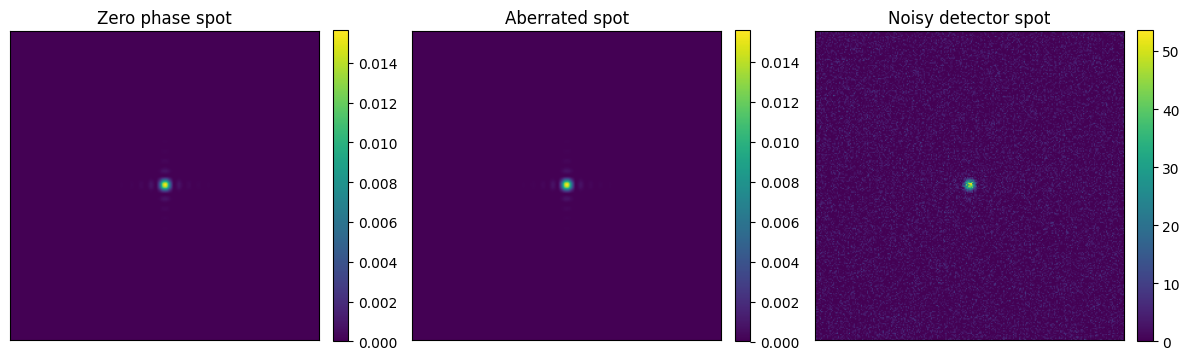

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, img, title in zip(
    axes,
    [spot0, spot_ab, spot_noisy],
    ["Zero phase spot", "Aberrated spot", "Noisy detector spot"],
):
    im = ax.imshow(img, origin="lower")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 3. Detector-level response matrix reconstruction

Now we build a response matrix where each column is the centroid-shift signal caused by one unit Zernike mode.  This is analogous to the previous slope response matrix, but the measurement vector is now composed of detector centroid shifts rather than analytic slopes.


In [39]:
A_det, names, centers, lenslet_masks, reference = build_detector_response_matrix(
    modes,
    pupil_mask,
    X,
    Y,
    n_lenslets=n_lenslets,
    min_fill=min_fill,
    pad_factor=pad_factor,
    threshold_fraction=centroid_threshold,
)

print(f"Detector response matrix shape: {A_det.shape}")
print(f"Valid lenslets: {len(centers)}")
print(f"Condition number: {np.linalg.cond(A_det):.2e}")

Detector response matrix shape: (104, 14)
Valid lenslets: 52
Condition number: 5.18e+00


In [40]:
_, shifts = measure_centroid_shifts(
    W_true,
    pupil_mask,
    X,
    Y,
    n_lenslets=n_lenslets,
    min_fill=min_fill,
    pad_factor=pad_factor,
    photons=None,
    read_noise_e=0.0,
    background_e=0.0,
    threshold_fraction=centroid_threshold,
    reference=reference,
    masks=lenslet_masks,
    centers=centers,
)

coeffs_rec, residuals, rank, singular_values = reconstruct_from_centroid_shifts(
    shifts,
    A_det,
    rcond=1e-4,
)

W_rec = synthesize_from_coefficients(
    coeffs_rec,
    modes,
    names,
    pupil_mask,
    remove_mean=True,
)
W_res = residual_wavefront(W_true, W_rec, pupil_mask)

print(f"Matrix rank: {rank} / {A_det.shape[1]}")
print(f"True RMS:        {rms(W_true, pupil_mask):.5f} rad")
print(f"Reconstructed RMS:{rms(W_rec, pupil_mask):.5f} rad")
print(f"Residual RMS:    {rms(W_res, pupil_mask):.5f} rad")

Matrix rank: 14 / 14
True RMS:        0.29268 rad
Reconstructed RMS:0.30211 rad
Residual RMS:    0.01328 rad


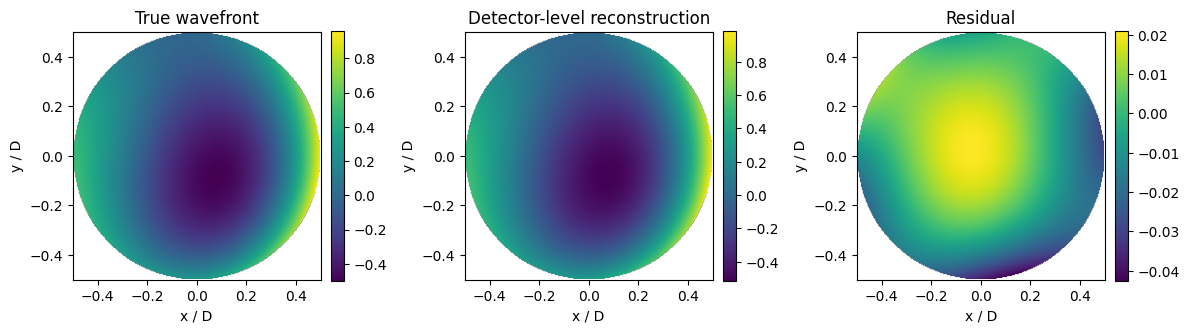

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))
for ax, img, title in zip(
    axes,
    [W_true, W_rec, W_res],
    ["True wavefront", "Detector-level reconstruction", "Residual"],
):
    im = ax.imshow(img, origin="lower", extent=[-0.5, 0.5, -0.5, 0.5])
    ax.set_title(title)
    ax.set_xlabel("x / D")
    ax.set_ylabel("y / D")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [42]:
print("Recovered modal coefficients:")
for name, value in zip(names, coeffs_rec):
    if abs(value) > 1e-3 or name in true_coeffs:
        print(f"{name:7s}  recovered={value:+.5f}   true={true_coeffs.get(name, 0.0):+.5f}")

Recovered modal coefficients:
Z1_+1    recovered=+0.00453   true=+0.00000
Z1_-1    recovered=-0.00621   true=+0.00000
Z2_+0    recovered=+0.26018   true=+0.25000
Z2_+2    recovered=+0.12096   true=+0.12000
Z3_+1    recovered=+0.07989   true=+0.08000
Z3_-1    recovered=-0.05138   true=-0.05000
Z4_+0    recovered=-0.00124   true=+0.00000
Z4_+2    recovered=-0.00107   true=+0.00000
Z4_+4    recovered=+0.00180   true=+0.00000
Z4_-4    recovered=+0.00222   true=+0.00000



## 4. Photon/read-noise sensitivity

The main reason to simulate detector spots is that the WFS measurement is no longer noise-free.  At low photon counts, centroid estimates become noisy and modal reconstruction degrades.  This is one of the most important differences between a geometric model and a detector-level model.


In [43]:
photon_levels = [1_000_000, 100_000, 30_000, 10_000, 3_000]

scan = centroid_noise_scan(
    W_true,
    A_det,
    modes,
    names,
    pupil_mask,
    X,
    Y,
    photon_levels=photon_levels,
    n_lenslets=n_lenslets,
    min_fill=min_fill,
    pad_factor=pad_factor,
    read_noise_e=read_noise_e,
    background_e=0.0,
    threshold_fraction=centroid_threshold,
    n_trials=8,
    seed=123,
    rcond=1e-4,
)

for photons, stats in scan.items():
    print(
        f"photons={photons:9.0f}  "
        f"mean residual RMS={stats['mean_residual_rms']:.5f} rad  "
        f"std={stats['std_residual_rms']:.5f} rad"
    )

photons=  1000000  mean residual RMS=0.01372 rad  std=0.00101 rad
photons=   100000  mean residual RMS=0.01682 rad  std=0.00343 rad
photons=    30000  mean residual RMS=0.02348 rad  std=0.00627 rad
photons=    10000  mean residual RMS=0.03255 rad  std=0.00550 rad
photons=     3000  mean residual RMS=0.56034 rad  std=0.14166 rad


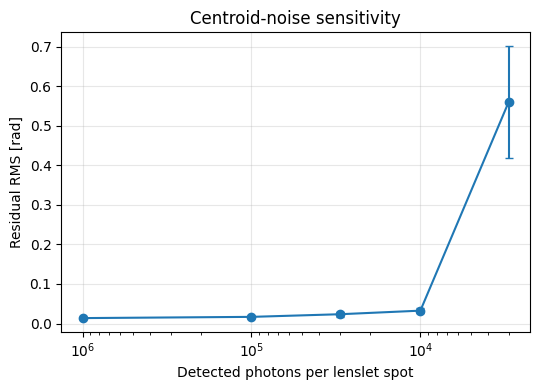

In [44]:
photons = np.array(list(scan.keys()), dtype=float)
mean_rms = np.array([scan[p]["mean_residual_rms"] for p in photons])
std_rms = np.array([scan[p]["std_residual_rms"] for p in photons])

plt.figure(figsize=(5.5, 4))
plt.errorbar(photons, mean_rms, yerr=std_rms, marker="o", capsize=3)
plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("Detected photons per lenslet spot")
plt.ylabel("Residual RMS [rad]")
plt.title("Centroid-noise sensitivity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Conclusion

This notebook extends the previous geometric Shack-Hartmann model to a detector-level centroiding model. Instead of directly averaging local wavefront gradients, each lenslet forms a diffraction spot, and the local wavefront slope is inferred from the spot centroid shift.

For the chosen test wavefront, the detector-level response matrix has shape \(104 \times 14\), full rank, and a low condition number of approximately 5.2. The noiseless thresholded-centroid reconstruction recovers the input low-order Zernike coefficients accurately, with a residual RMS of about 0.013 rad compared to an input RMS of about 0.293 rad.

The photon/read-noise scan shows the expected behaviour: at high photon counts, the residual is dominated by centroid threshold bias and remains close to the noiseless level; as the photon count decreases, centroid noise increases the residual. At very low photon counts, the centroid estimate becomes unstable and the reconstruction enters a low-SNR failure regime.
